# Data Import

In [13]:
import os
import json
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

root_path = "/nas/Dataset/Dataset_2025/dataset_v1"

def load_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)

def process_one_conf(args):
    """개별 conf 파일 + grasp 파일 처리 (서브 프로세스에서 실행)"""
    root_path, env, section, platform, conf_name = args

    conf_path = os.path.join(root_path, env, section, platform, "conf", conf_name)
    grasp_path = os.path.join(root_path, env, section, platform, "output_grasp", conf_name)

    conf_data = load_json(conf_path)
    grasp_data = load_json(grasp_path)

    platform_name = conf_data["platform"]["name"]

    # 부분 결과 로컬 dict로 집계
    local_grasp = Counter()
    local_freq = Counter()

    for grasp in grasp_data:
        local_grasp[grasp["target_object"]] += 1

    for obj in conf_data["objects"]:
        local_freq[obj["class"]] += 1

    # env별 platform 이름도 넘겨줌
    return env, platform_name, local_grasp, local_freq


def main():
    # 1) 작업 리스트 만들기 (env / section / platform / conf_name)
    tasks = []

    env_list = [e for e in os.listdir(root_path)
                if os.path.isdir(os.path.join(root_path, e))]

    for env in env_list:
        section_list = [s for s in os.listdir(os.path.join(root_path, env))
                        if os.path.isdir(os.path.join(root_path, env, s))]
        for section in section_list:
            platform_list = [p for p in os.listdir(os.path.join(root_path, env, section))
                             if os.path.isdir(os.path.join(root_path, env, section, p))]
            for platform in platform_list:
                conf_dir = os.path.join(root_path, env, section, platform, "conf")
                conf_files = [c for c in os.listdir(conf_dir) if c.endswith(".json")]

                for name in conf_files:
                    tasks.append((root_path, env, section, platform, name))

    # 2) 결과 저장용
    platform_dict = defaultdict(list)
    grasp_dict = Counter()
    freq_dict = Counter()

    # 3) 병렬 실행
    with ProcessPoolExecutor() as ex:
        for env, platform_name, local_grasp, local_freq in tqdm(
            ex.map(process_one_conf, tasks),
            total=len(tasks)
        ):
            platform_dict[env].append(platform_name)
            grasp_dict.update(local_grasp)
            freq_dict.update(local_freq)

    # 필요하면 여기서 platform_dict, grasp_dict, freq_dict 사용
    return platform_dict, grasp_dict, freq_dict


if __name__ == "__main__":
    platform_dict, grasp_dict, freq_dict = main()


100%|██████████| 100690/100690 [22:54<00:00, 73.27it/s] 


In [2]:
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

def load_json(file_path):
    """Load a JSON file and return its content."""
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data



platform_dict = {}
grasp_dict = {}
freq_dict = {}

root_path = "/nas/Dataset/Dataset_2025/dataset_v1"
env_list = [i for i in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, i))]
for env in env_list:
    platform_dict[env] = []
    section_list = [i for i in os.listdir(os.path.join(root_path, env)) if os.path.isdir(os.path.join(root_path, env, i))]
    for section in section_list:
        platform_list = [i for i in os.listdir(os.path.join(root_path, env, section)) if os.path.isdir(os.path.join(root_path, env, section, i))]
        for platform in platform_list:
            conf_path = os.path.join(root_path, env, section, platform, "conf")
            conf_path_list = [i for i in os.listdir(conf_path) if i.endswith(".json")]


            for name in tqdm(conf_path_list):
                conf_data = load_json(os.path.join(conf_path, name))
                # grasp_data = load_json(os.path.join(root_path,env,section,platform, "output_grasp", name))
                platform_dict[env].append(conf_data["platform"]["name"])
                # for grasp in grasp_data:
                #     if grasp["target_object"] in grasp_dict:
                #         grasp_dict[grasp["target_object"]] +=1
                #     else:
                #         grasp_dict[grasp["target_object"]] = 1
                for obj in conf_data["objects"]:
                    if obj["class"] in freq_dict:
                        freq_dict[obj["class"]] += 1
                    else:
                        freq_dict[obj["class"]] = 1

100%|██████████| 3501/3501 [00:06<00:00, 581.01it/s]


# Platform Freq

In [27]:
values

array([4501, 4513, 4017, 4500, 5136, 3501, 4501, 4501])

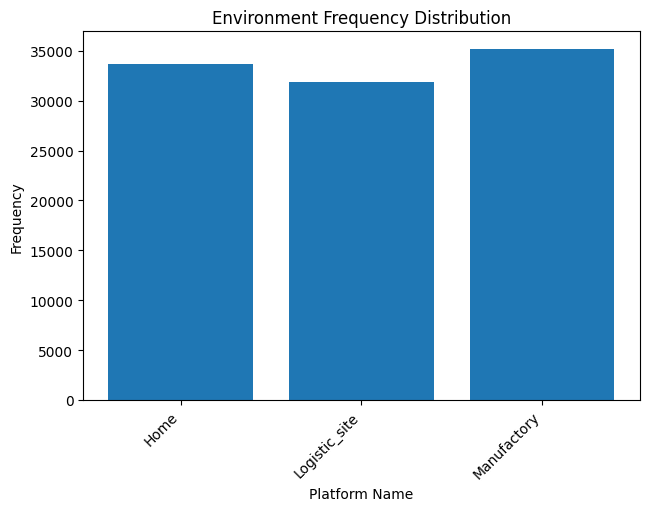

In [29]:
env_names =["Home","Logistic_site", "Manufactory"]
env_data_cnt = []
for env_name in env_names:
        
    data,values = np.unique(platform_dict[env_name], return_counts=True)
    env_data_cnt.append(values.sum())

plt.bar(env_names, env_data_cnt)
plt.xticks(rotation=45, ha='right')  # 45도 회전 + 오른쪽 정렬
plt.tight_layout()  # 레이아웃 자동 조정
plt.xlabel('Platform Name')
plt.ylabel('Frequency')
plt.title('Environment Frequency Distribution')
plt.show()

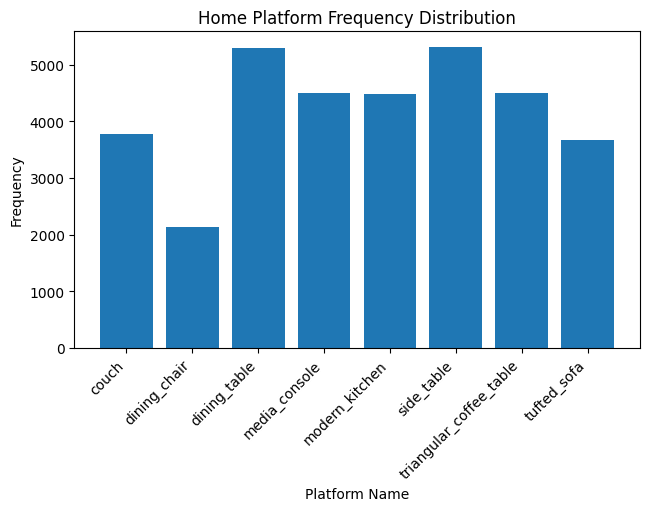

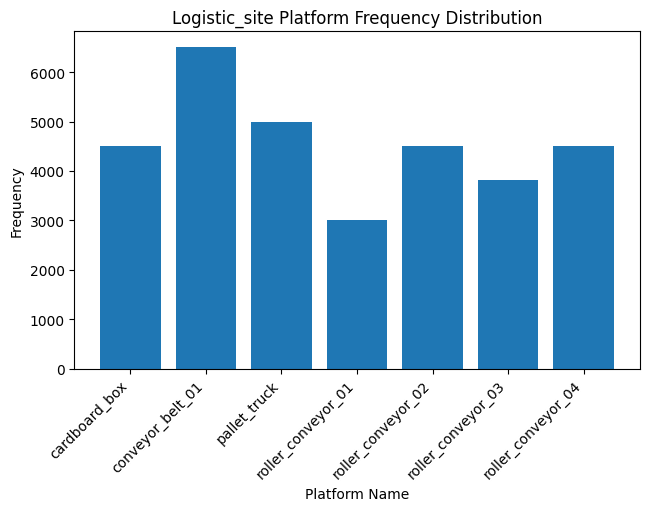

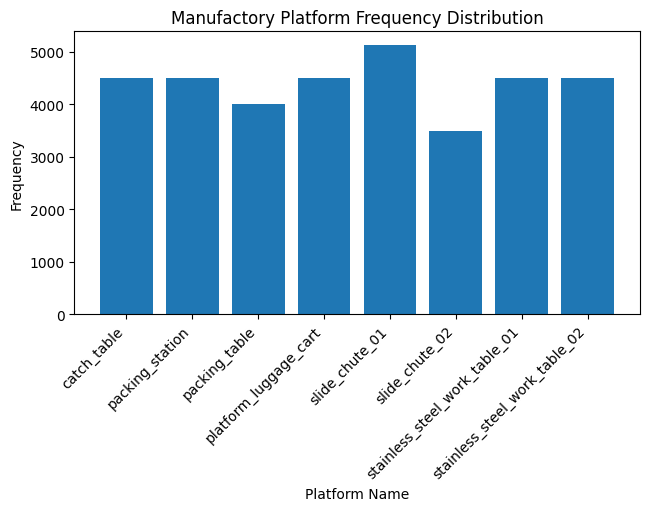

In [26]:
env_names =["Home","Logistic_site", "Manufactory"]
for env_name in env_names:
        
    data,values = np.unique(platform_dict[env_name], return_counts=True)
    plt.bar(data, values)
    plt.xticks(rotation=45, ha='right')  # 45도 회전 + 오른쪽 정렬
    plt.tight_layout()  # 레이아웃 자동 조정
    plt.xlabel('Platform Name')
    plt.ylabel('Frequency')
    plt.title(f'{env_name} Platform Frequency Distribution')
    plt.show()

# object Freq, Grasp

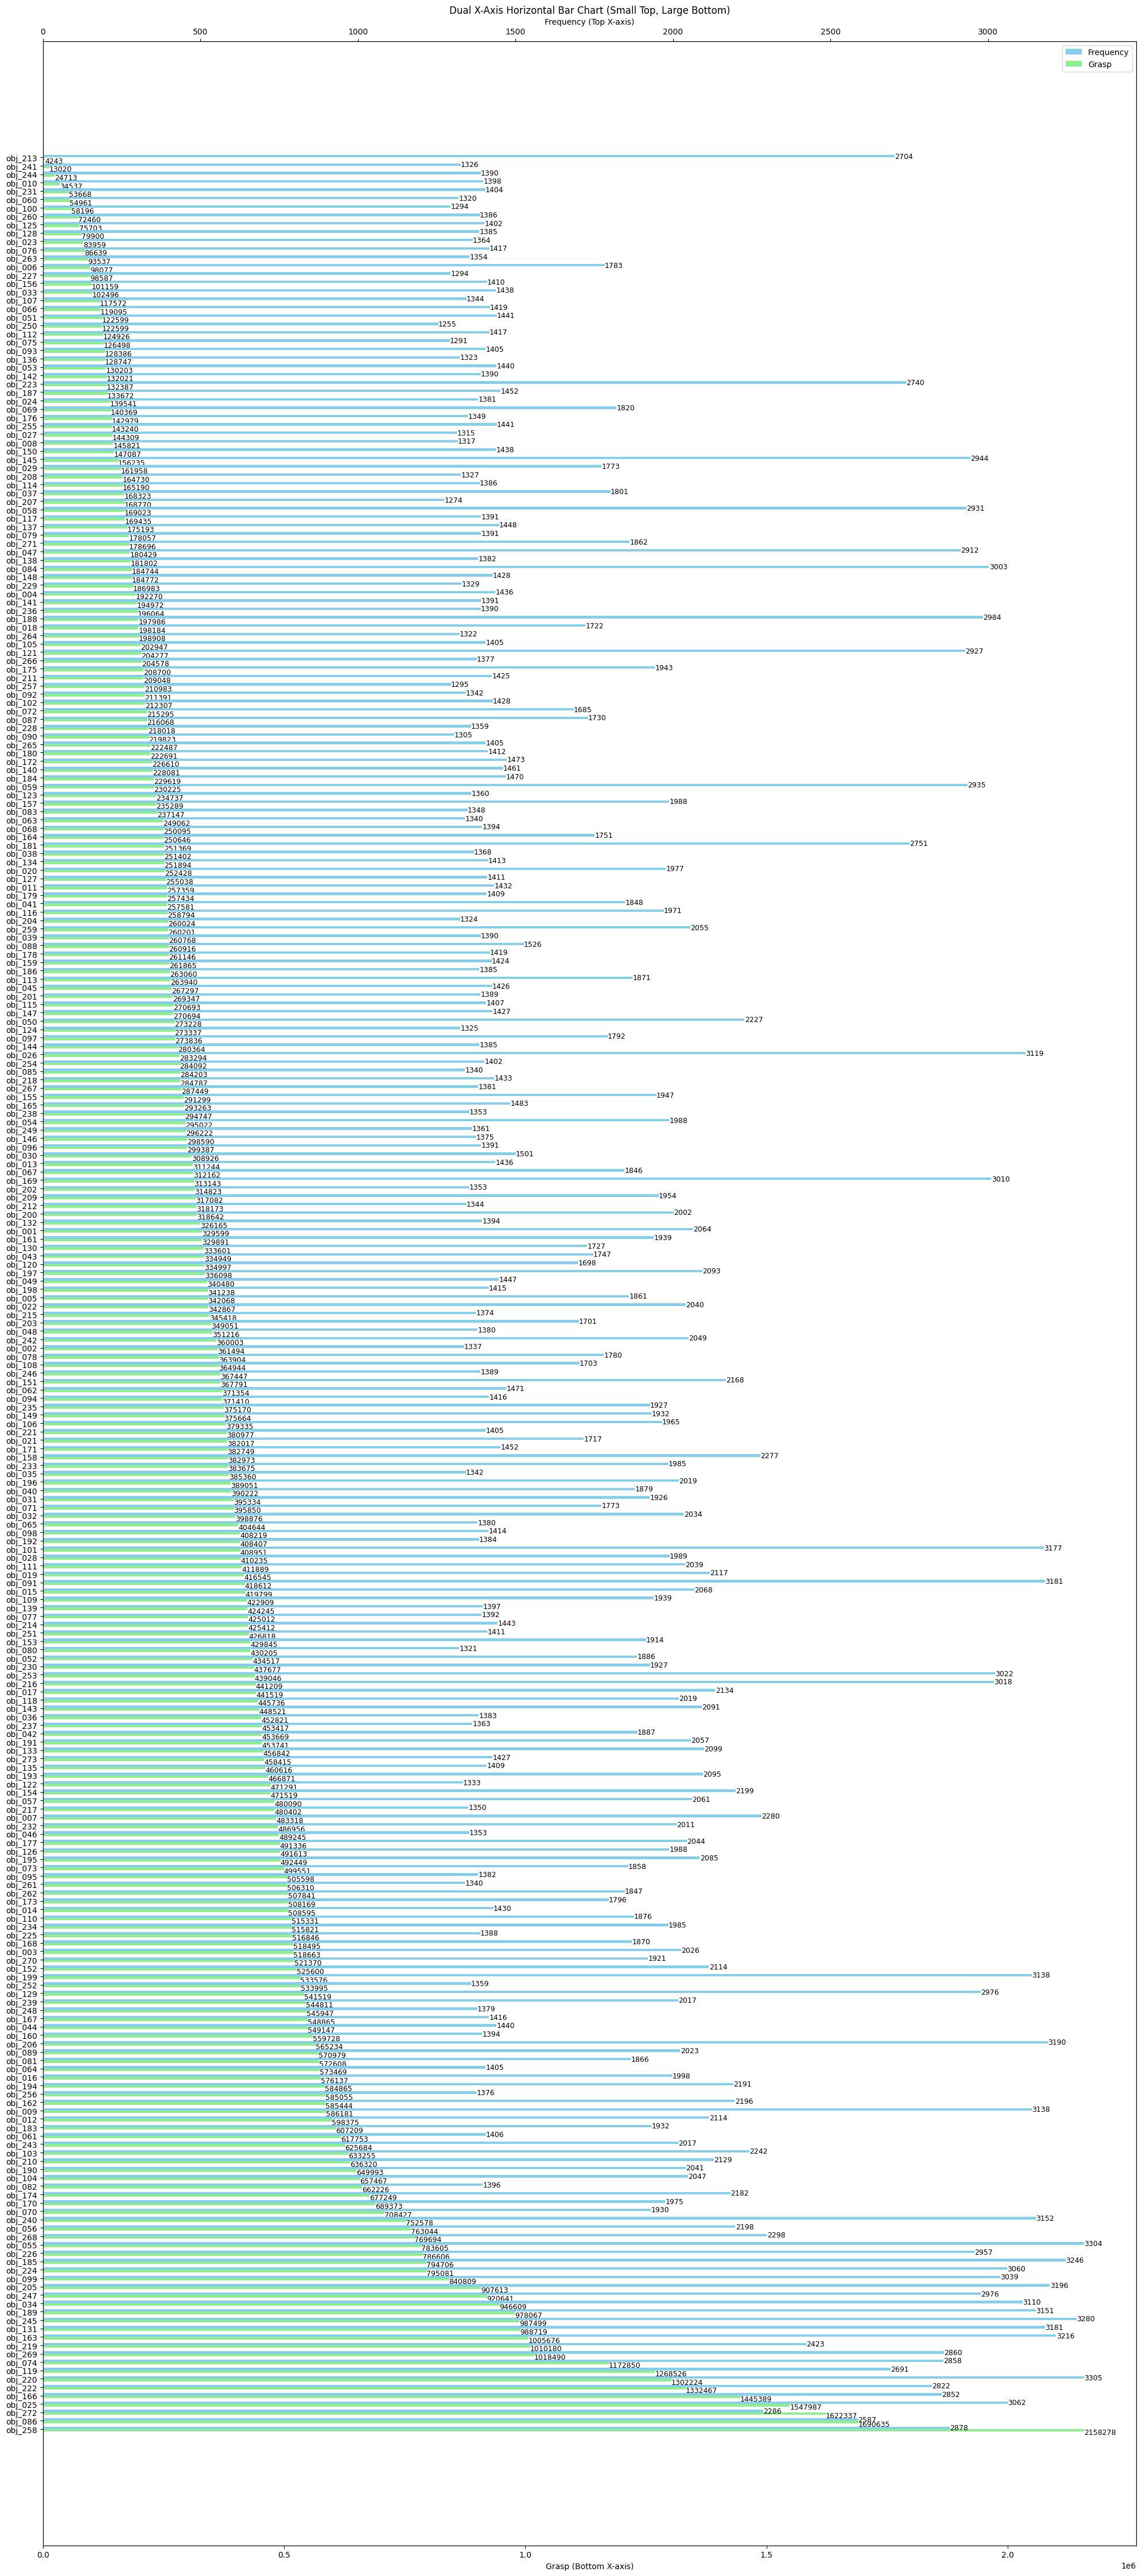

In [25]:
import matplotlib.pyplot as plt
import numpy as np

data,value1 = grasp_dict.keys(), grasp_dict.values()
data = sorted(data, key=lambda x: grasp_dict[x], reverse=False)
value1 = [grasp_dict[key] for key in data]
data2, value2 = freq_dict.keys(), freq_dict.values()
data2 = sorted(data2, key=lambda x: grasp_dict[x], reverse=False)
value2 = [freq_dict[key] for key in data2]

y_pos = np.arange(len(data))

fig, ax_bottom = plt.subplots(figsize=(20, 45))
ax_top = ax_bottom.twiny()

bar_height = 0.3

# 🎯 큰 값 → 아래쪽 (아래쪽 x축)
bar_bot = ax_bottom.barh(y_pos + bar_height/2, value1, height=bar_height, color='lightgreen', label='Grasp')
for i, v in enumerate(value1):
    ax_bottom.text(v + 3, y_pos[i] + bar_height/2+0.25, str(v), va='center', fontsize=9)
ax_bottom.set_yticks(y_pos)
ax_bottom.set_yticklabels(data)
ax_bottom.set_xlabel('Grasp (Bottom X-axis)')
ax_bottom.invert_yaxis()

# 🎯 작은 값 → 위쪽 (위쪽 x축)
bar_top = ax_top.barh(y_pos - bar_height/2, value2, height=bar_height, color='skyblue', label='Frequency')
for i, v in enumerate(value2):
    ax_top.text(v + 0.5, y_pos[i] - bar_height/2, str(v), va='center', fontsize=9)
ax_top.set_xlabel('Frequency (Top X-axis)')
ax_top.xaxis.set_label_position('top')
ax_top.xaxis.tick_top()

handles = [bar_top[0], bar_bot[0]]
labels = ['Frequency', 'Grasp']
ax_bottom.legend(handles, labels, loc='upper right')


plt.title('Dual X-Axis Horizontal Bar Chart (Small Top, Large Bottom)')
plt.tight_layout()

plt.show()


# Gripper

## Gripper Freq